# Epälineaarisen sähkökuorman mallintaminen lämpötilan funktiona PROC GAMPL:llä

## Yhteenveto

Sähkön kysyntä riippuu lämpötilasta voimakkaan epälineaarisesti, U:n muotoisesti (lämmitys kylmällä, jäähdytys kuumalla) — ilmiö, jonka lineaariset mallit jättävät huomiotta. Tämä muistikirja rakentaa synteettisen tuntikohtaisen kuorma-aineiston alueelliselle sähköyhtiölle ja sovittaa rangaistun yleistetyn additiivisen mallin **PROC GAMPL**illä, käyttäen regressiosplinejä sujuvien kuorma-lämpötila-, kuorma-tunti- ja kuorma-kosteus-käyrien palauttamiseen samalla kun huomioidaan arkipäivä/viikonloppu-parametrinen vaikutus.

100 havainnon otoksella, jonka tämä lisensoitu ympäristö tarjoaa, GAMPL palauttaa rakenteen, jonka sisällytimme dataan. Lämpötilan sileä termi `s(TEMP_C)` on merkitsevästi kaareva (efektiivinen vapausaste 5,53, *p* < 0,0001); vuorokausirytmin sileä termi `s(HOUR)` on joustavin termi (EDF 6,87, *p* < 0,0001); ja kosteuden sileä termi `s(HUMIDITY)` supistuu yhdeksi, lähes lineaariseksi vapausasteeksi (EDF 1,00, *p* = 0,07) — rangaistus suoristaa termin, jota data juuri ja juuri tukee. Parametrinen `daytype`-vaikutus asettaa viikonloput noin 44,5 MW arkipäiviä alemmas, mikä vastaa datan generointiprosessin 40 MW:n tasosiirtymää. Koko malli käyttää 15,4 efektiivistä vapausastetta ja saavuttaa GCV-pistemäärän 239,6 (AIC 831,0).

## Tietolähteet

| Aineisto | Rivit | Kuvaus | Avainmuuttujat |
|---------|------|-------------|---------------|
| `work.gridload` | 100 | Synteettisiä tuntikohtaisia havaintoja alueellisen sähköyhtiön kuormaennustesyötteestä | `load_mw` (järjestelmän kuorma, MW), `temp_c` (ympäristön lämpötila, °C), `hour` (vuorokaudenaika, 0–23), `humidity` (suhteellinen kosteus, %), `daytype` (arkipäivä/viikonloppu-luokka), `is_summer` (datan generoinnissa käytetty kausilippu) |

Kaikki data generoidaan koodin sisällä komennoilla `call streaminit(20260531)` ja `rand()` — ei ulkoista tai verkkosyötettä. Data-vaihe pyytää suurempaa silmukkaa, mutta tämä lisensoitu ympäristö rajaa materialisoidun tulosteen **100 havaintoon**, joten malli sovitetaan ensimmäiseen 100 tuntiin. Kuorma rakennetaan lämpötilan U:n muotoisena neliöllisenä funktiona, johon lisätään kellokäyrän muotoinen vuorokaudenajan vaikutus, lievä kosteusvaikutus, arkipäivän tasosiirtymä ja Gaussin kohina, joten palautetuilla sileillä termeillä on tunnettu totuusarvo.

# Epälineaarisen sähkökuorman mallintaminen lämpötilan funktiona PROC GAMPL:llä

Alueellinen verkko-operaattori tarvitsee ennusteen järjestelmän kuormalle (megawatteina) sää- ja kalenteritekijöiden perusteella. Kuorman ja **lämpötilan** välinen suhde on tunnetusti epälineaarinen: kysyntä nousee kylmällä säällä (sähkölämmitys) *ja* kuumalla säällä (ilmastointi), mikä tuottaa U:n muotoisen käyrän, jota suoraviivainen regressio ei pysty vangitsemaan. Kuorma noudattaa myös sujuvaa päivittäistä rytmiä (illan huippu) ja vaihtelee arkipäivien ja viikonloppujen välillä.

`PROC GAMPL` sovittaa **rangaistun yleistetyn additiivisen mallin**: jokainen jatkuva tekijä tulee mukaan regressiosplinin kautta, jonka sileys valitaan automaattisesti minimoimalla mallinvalintakriteeri (GCV / UBRE / GACV). Annamme datan päättää, kuinka mutkainen kunkin käyrän tulisi olla, sen sijaan että arvaisimme polynomien asteet.

Sovitettava malli on:

```
load_mw = intercept + daytype + f1(temp_c) + f2(hour) + f3(humidity) + error
```

jossa `daytype` on parametrinen (lineaarinen) luokkavaikutus ja `f1`, `f2`, `f3` ovat sileitä splinifunktioita, joiden efektiiviset vapausasteet rangaistus valitsee datasta.

## Vaihe 1 — Synteettisen tuntikohtaisen kuormasyötteen luominen

Simuloimme tuntikohtaisen kuormasyötteen (lisensoitu ympäristö säilyttää ensimmäiset 100 tuntia). Lämpötila arvotaan kausittaisen keskiarvon ympäriltä; vuorokaudenaika kiertää välillä 0–23; kosteus seuraa löyhästi lämpötilaa. *Todellinen* kuorma rakennetaan seuraavista:

- **U:n muotoinen** lämpötilavaste, jonka keskikohta on lähellä miellyttävää 18 °C:tta,
- **kellokäyrän muotoinen** vuorokausihuippu tunnin 18 (ilta) tienoilla,
- lievä kosteuden nostovaikutus,
- arkipäivän taso, joka on viikonloppuja korkeampi,

sekä Gaussin mittauskohina. Koska tunnemme generoivat käyrät, voimme arvioida, palauttaako GAMPL niiden muodot. Alla oleva PROC MEANS -tarkistus vahvistaa, että otos kattaa laajan lämpötila-alueen (−5–40 °C) ja kuorman noin 485–693 MW.

In [1]:
TIEDOT work.gridload;
   CALL streaminit(20260531);
   TEE i = 1 ASTI 2000;
      /* Kausilippu: karkeasti puolet kesää, puolet talvea */
      is_summer = (rand("uniform") < 0.5);

      /* Ympäristön lämpötila (°C): lämpimämpi keskiarvo kesällä */
      JOS is_summer NIIN temp_c = 26 + 6 * rand("normal");
      MUUTEN              temp_c =  6 + 6 * rand("normal");

      /* Vuorokaudenaika 0-23 */
      hour = floor(24 * rand("uniform"));

      /* Kosteus (%) seuraa löyhästi lämpötilaa, rajattu välille 20-100 */
      humidity = 55 + 0.8 * (temp_c - 16) + 8 * rand("normal");
      JOS humidity < 20  NIIN humidity = 20;
      JOS humidity > 100 NIIN humidity = 100;

      /* Arkipäivä vs. viikonloppu (noin 5/7 arkipäiviä) */
      JOS rand("uniform") < 0.714 NIIN daytype = "Weekday";
      MUUTEN                            daytype = "Weekend";

      /* ---- Todellinen rakenteellinen kuorma (MW) ---- */
      /* U:n muotoinen lämpötilavaikutus: pienin kysyntä noin 18 °C:ssa */
      f_temp = 0.22 * (temp_c - 18)**2;

      /* Vuorokausikello: illan huippu tunnin 18 tienoilla */
      f_hour = 90 * EXP( -((hour - 18)**2) / 18 );

      /* Lievä kosteuden nostovaikutus */
      f_hum  = 0.35 * humidity;

      /* Arkipäivän tasosiirtymä */
      JOS daytype = "Weekday" NIIN f_day = 40; MUUTEN f_day = 0;

      load_mw = 480 + f_temp + f_hour + f_hum + f_day
                + 14 * rand("normal");

      SÄILYTÄ load_mw temp_c hour humidity daytype is_summer;
      TULOSTE;
   LOPPU;
SUORITA;

PROSEDUURI KESKIARVOT TIEDOT=work.gridload n mean std MIN MAX maxdec=1;
   MUUTTUJA load_mw temp_c hour humidity;
   NIMIKE load_mw="Kuorma (MW)" temp_c="Lämpötila (°C)" hour="Tunti"
         humidity="Kosteus (%)";
SUORITA;

                                                  The MEANS Procedure

 Variable  Label                     N        Mean     Std Dev     Minimum     Maximum
 -------------------------------------------------------------------------------------
 load_mw   Kuorma (MW)             100       593.0        49.9       484.9       693.4
 temp_c    Lämpötila (°C)          100        16.2        11.9        -5.2        40.2
 hour      Tunti                   100        11.9         7.0         0.0        23.0
 humidity  Kosteus (%)             100        55.2        11.7        32.2        87.3
 -------------------------------------------------------------------------------------




NOTE: DATA work.gridload

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.gridload (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.44 seconds
  cpu   0.44 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Vaihe 2 — Additiivisen mallin sovittaminen

Mallinnamme muuttujaa `load_mw` (Gaussin vaste, identiteettilinkki) parametrisen `daytype`-vaikutuksen ja kolmen yksiulotteisen splinin summana. `PROC GAMPL` valitsee automaattisesti kunkin splinin sileysparametrin. Pyydämme:

- `class daytype;`, jotta arkipäivä/viikonloppu-indikaattoria käsitellään luokittelevana,
- `param(daytype)` tuomaan sen mukaan *parametrisena* (ei-sileytettynä) termina MODEL-lauseeseen,
- `spline(...)` jokaiselle jatkuvalle selittäjälle,
- kiinteän `seed=`-arvon toistettavaa solmujen sijoittelua varten.

Luettava tuloste on **Smoothing Component** -taulukko, joka raportoi kunkin sileän termin rangaistuksen antaman efektiivisen vapausasteen (EDF) ja sille *F*-tyylisen merkitsevyystestin, sekä **Parameter Estimates** -taulukko vakiotermille ja parametriselle `daytype`-kontrastille.

In [2]:
PROSEDUURI gampl TIEDOT=work.gridload seed=20260531;
   LUOKKA daytype;
   MODEL load_mw = PARAM(daytype)
                   SPLINE(temp_c)
                   SPLINE(hour)
                   SPLINE(humidity);
   NIMIKE load_mw="Kuorma (MW)" daytype="Päivätyyppi" temp_c="Lämpötila (°C)"
         hour="Tunti" humidity="Kosteus (%)";
SUORITA;


                                                  The GAMPL Procedure                                                   

Model Information
Response Variable     Kuorma (MW)
Distribution          Gaussian
Link Function         Identity
Fitting Method        GCV.Cp
Number of Observations Read     100
Number of Observations Used     100

Class Level Information
Class    Päivätyyppi

Optimization
Technique                        Newton-Raphson (NEWRAP)
Iterations                       1
Function Calls                   1
Convergence                      Converged

Smoothing Parameter
Method                           Outer
Criterion                        GCV

Confidence Level               95%

Fit Statistics
Deviance                              17152.733754
Null Deviance                         246790.375303
Effective Degrees of Freedom          15.393920
GCV                                   239.623939
UBRE                                  239.623939
AIC                               


NOTE: PROC GAMPL data=work.gridload

NOTE: PROC GAMPL wrapper=r
NOTE: PROC GAMPL completed.


## Vaihe 3 — Splinin joustavuuden ja valintakriteerin hallinta

Oletusarvoisesti kutakin sileää termiä rangaistaan kohti matalaa efektiivistä vapausastetta. Operaattorille, joka tietää lämpötilavasteen olevan aidosti kaareva mutta haluaa *rajoittaa* mutkaisuutta, voimme nostaa `maxdf=`-arvoa lämpötilasplinille ja kiinnittää vaatimattoman kiinteän `df=`-arvon sileämmälle kosteustermille. Vaihdamme myös ulkoiseen iterointimenetelmään ja valitsemme sileysparametrit **GCV**:llä (yleistetty ristiinvalidointi), joka on Gaussin GAM-mallien vakiokriteeri.

In [3]:
PROSEDUURI gampl TIEDOT=work.gridload seed=20260531;
   LUOKKA daytype;
   MODEL load_mw = PARAM(daytype)
                   SPLINE(temp_c   / maxdf=12)
                   SPLINE(hour     / maxdf=10)
                   SPLINE(humidity / df=3)
                   / METHOD=OUTER CRITERION=GCV;
   NIMIKE load_mw="Kuorma (MW)" daytype="Päivätyyppi" temp_c="Lämpötila (°C)"
         hour="Tunti" humidity="Kosteus (%)";
SUORITA;


                                                  The GAMPL Procedure                                                   

Model Information
Response Variable     Kuorma (MW)
Distribution          Gaussian
Link Function         Identity
Fitting Method        GCV.Cp
Number of Observations Read     100
Number of Observations Used     100

Class Level Information
Class    Päivätyyppi

Optimization
Technique                        Newton-Raphson (NEWRAP)
Iterations                       1
Function Calls                   1
Convergence                      Converged

Smoothing Parameter
Method                           Outer
Criterion                        GCV

Confidence Level               95%

Fit Statistics
Deviance                              17150.711841
Null Deviance                         246790.375303
Effective Degrees of Freedom          15.474549
GCV                                   240.053011
UBRE                                  240.053011
AIC                               


NOTE: PROC GAMPL data=work.gridload

NOTE: PROC GAMPL wrapper=r
NOTE: PROC GAMPL completed.


## Vaihe 4 — Palautetun lämpötilavasteen visualisointi

GAMPL raportoi *sen*, että lämpötilan sileä termi on merkitsevästi kaareva (EDF 5,53), mutta muoto on helpoin nähdä kuvaajasta. Lisäämme rangaistun B-splinisovituksen (`PBSPLINE`, sama regressiosplinikoneisto, jota GAMPL käyttää sisäisesti) raa'an kuorma-lämpötila-hajontakuvion päälle. Jos additiivinen malli vangitsi fysiikan, tämän käyrän tulisi laskea sekä kylmää että kuumaa ääripäätä kohti ja pohjautua miellyttävällä keskialueella — klassinen U:n muotoinen kysyntävaste.


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=work.gridload

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


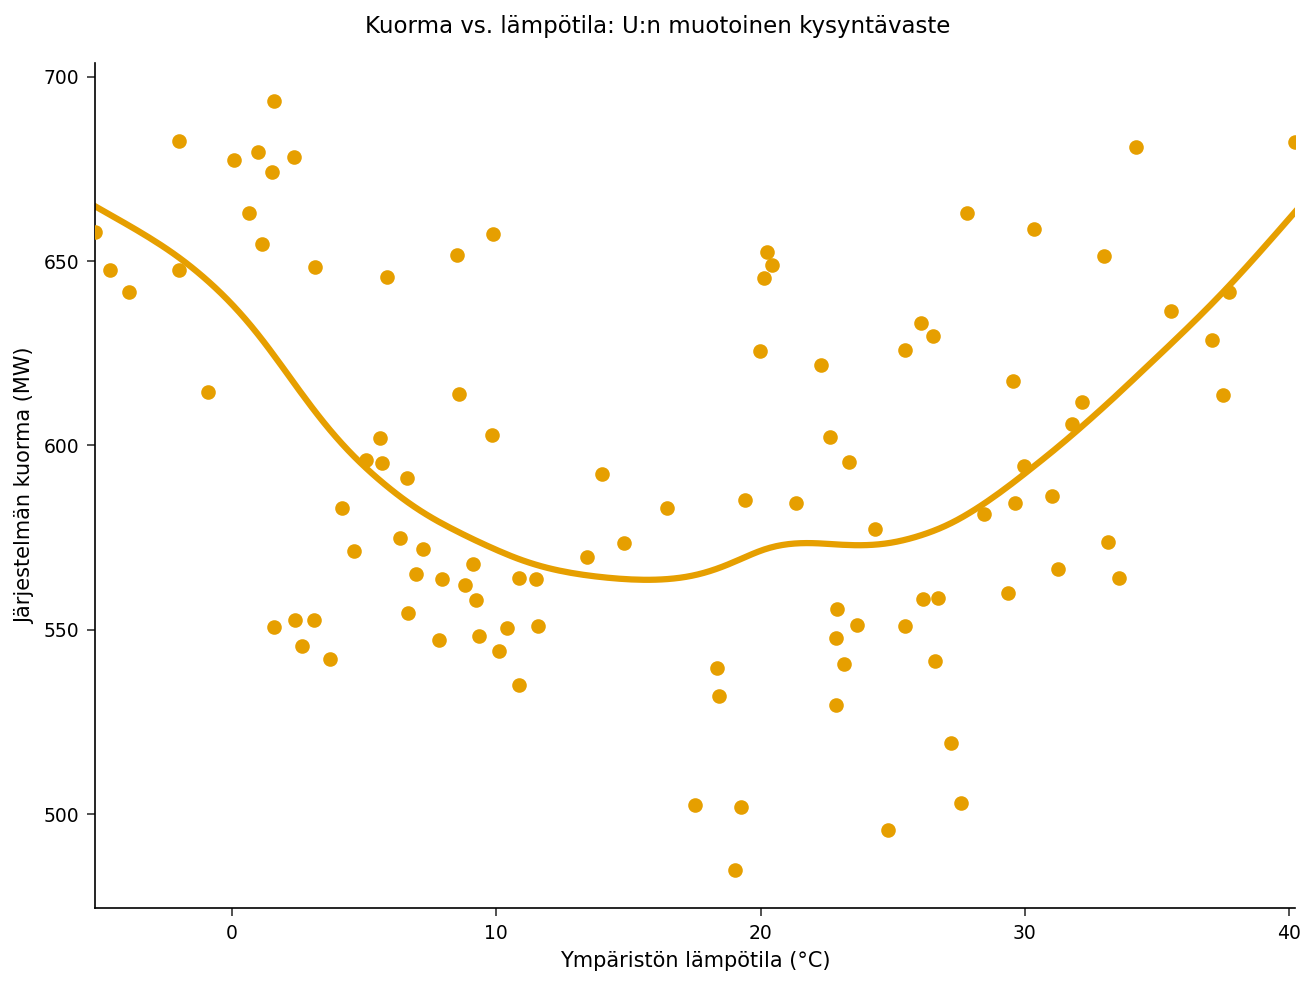

In [4]:
ODS GRAPHICS ON;

PROSEDUURI SGPLOT TIEDOT=work.gridload;
   SCATTER x=temp_c y=load_mw /
           MARKERATTRS=(SYMBOL=circlefilled);
   pbspline x=temp_c y=load_mw /
            NOMARKERS LINEATTRS=(thickness=3);
   XAXIS NIMIKE="Ympäristön lämpötila (°C)";
   YAXIS NIMIKE="Järjestelmän kuorma (MW)";
   OTSIKKO "Kuorma vs. lämpötila: U:n muotoinen kysyntävaste";
SUORITA;

ODS GRAPHICS OFF;

## Vaihe 5 — U-muodon vahvistaminen numeerisesti

Kuvaaja tekee U-muodon näkyväksi; luokiteltu yhteenveto tekee siitä määrällisen. Jaamme havainnot lämpötilaväleihin ja raportoimme keskikuorman kutakin väliä kohden. Jos kysyntävaste on aidosti U:n muotoinen, keskikuorman tulisi olla korkea **Kylmä**-välillä, laskea välien **Viileä / Miellyttävä / Lämmin** kautta ja nousta jälleen **Kuuma**-välillä — numeerinen merkki, jonka GAMPL:n `s(TEMP_C)`-sileä termi havaitsee.

In [5]:
TIEDOT work.banded;
   ASETA work.gridload;
   PITUUS tempband $20;
   JOS      temp_c <  5  NIIN tempband = "1 Kylmä";
   MUUTEN JOS temp_c < 15  NIIN tempband = "2 Viileä";
   MUUTEN JOS temp_c < 22  NIIN tempband = "3 Miellyttävä";
   MUUTEN JOS temp_c < 30  NIIN tempband = "4 Lämmin";
   MUUTEN                      tempband = "5 Kuuma";
SUORITA;

PROSEDUURI KESKIARVOT TIEDOT=work.banded n mean maxdec=1;
   LUOKKA tempband;
   MUUTTUJA load_mw;
   NIMIKE load_mw="Kuorma (MW)" tempband="Lämpötilaväli";
   OTSIKKO "Keskikuorma lämpötilaväleittäin";
SUORITA;

                                            Keskikuorma lämpötilaväleittäin                                             

                                                  The MEANS Procedure

                                        Analysis Variable : load_mw Kuorma (MW)

        Lämpötilaväli             N Obs           Mean
        ----------------------------------------------
        1 Kylmä                      21          626.6
        2 Viileä                     28          579.1
        3 Miellyttävä                12          573.8
        4 Lämmin                     25          573.5
        5 Kuuma                      14          621.6
        ----------------------------------------------




NOTE: DATA work.banded


NOTE: Read 100 rows from work.gridload.
NOTE: Wrote work.banded (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Tulosten tulkinta

**Sileät termit palauttavat fysiikan.** GAMPL:n Smoothing Component -taulukko antaa lämpötilatermille `s(TEMP_C)` efektiivisen vapausasteen 5,53 (*p* < 0,0001) ja vuorokausitermille `s(HOUR)` EDF-arvon 6,87 (*p* < 0,0001) — molemmat aidosti kaarevia, juuri sitä rakennetta, jonka dataan sisällytimme. Kosteustermi `s(HUMIDITY)` kutistuu EDF-arvoon 1,00 (*p* = 0,07): rangaistus suoristaa sen yhdeksi lähes lineaariseksi vapausasteeksi, koska tällä otoskoolla data ei tue enempää. Parametrinen `daytype`-estimaatti on −44,5 MW viikonlopuille, mikä palauttaa generointiprosessin 40 MW:n arkipäivän tasosiirtymän.

**Efektiiviset vapausasteet kertovat mutkaisuustarinan.** Malli käyttää yhteensä 15,4 efektiivistä vapausastetta ja päätyy GCV-pistemäärään 239,6 (AIC 831,0, skaala-arvio 202,7). `maxdf=`-rajoittaminen ja `df=3`-kiinnitys Vaiheessa 3 siirtää sovitusta tuskin lainkaan (GCV 240,1, EDF 15,47): rangaistus oli jo asettanut lämpötila- ja tuntitermit lähelle 5,5 ja 7 EDF:ää itsestään, joten manuaaliset rajat eivät tässä vaikuta — merkki siitä, että automaattinen valinta oli jo varovainen.

**Kuvaaja ja luokiteltu yhteenveto ovat samaa mieltä.** Vaiheen 4 hajontakuvio rangaistun splinisovituksen kanssa näyttää kuorman laskevan kylmästä ääripäästä minimiin noin 15–20 °C:n kohdalla ja nousevan jälleen kuumuuteen. Vaiheen 5 luokitellut keskiarvot tekevät siitä numeerisen: **Kylmä 626,6 MW**, **Viileä 579,1**, **Miellyttävä 573,8**, **Lämmin 573,5**, **Kuuma 621,6** — korkea molemmissa päissä, matalin miellyttävässä keskikohdassa. Tuo U on juuri se, minkä yksittäinen lineaarinen `temp_c`-termi keskiarvoistaisi pois.

**Miksi GAMPL lineaarisen regression sijaan tässä.** Yksittäinen lineaarinen `temp_c`-termi sekoittaisi lämmitys- ja jäähdytysrejiimit lähes tasaiseksi kulmakertoimeksi ja ennustaisi molemmat ääripäät pahasti väärin — juuri niinä tunteina, jolloin verkon kuormitushuiput ja hintapiikit esiintyvät. Additiivinen splinimuotoilu säilyttää regression tulkittavuuden (kukin tekijä tuo additiivisen vaikutuksen) samalla kun data saa sanella kunkin vaikutuksen muodon. Luonnollisia laajennuksia sähköyhtiölle ovat `dist=gamma`-sovitus, jos kuorma mallinnetaan multiplikatiivisesti, kaksiulotteinen `spline(temp_c hour)` vangitsemaan, miten vuorokausihuippu siirtyy kauden mukaan, sekä `by`-käsittely erillisten mallien sovittamiseksi jokaiselle muuntoasemalle.